# Trend-Following Across a Diversified Futures Book

**NUS Investment Society — QR Department Recruitment AY26/27, Question 3**

*A time-series momentum strategy on 77 global futures markets, 1978–2014, validated out-of-sample and tested as an addition to a conventional portfolio.*

## Introduction

### What this is

A **time-series momentum (TSMOM)** strategy — go long a market that has risen over the past twelve months, short one that has fallen, size every position to the same volatility target, then hold the whole book to a constant risk level — traded across **77 futures markets** spanning currencies, government bonds, equity indices, energy, metals and agriculture.

### Why this, out of the three options in the brief

The brief suggests momentum/trend-following CTA, dynamic regime allocation, or volatility strategies. I chose trend-following and pursued it to depth rather than sampling all three, for three reasons:

1. **It is the most testable.** The signal is defined *a priori* by the literature (Moskowitz-Ooi-Pedersen 2012), so there are no parameters to fit and therefore little to overfit — the result is close to an out-of-sample test by construction.
2. **The dataset suits it.** 94 global futures markets across six asset classes is almost exactly the universe the canonical papers use; diversification across uncorrelated markets is where trend-following gets its edge, and §7 shows that quantitatively.
3. **Occam's razor, which the brief asks for explicitly.** The entire strategy is *sign of a twelve-month return, divided by recent volatility*. It fits in one line and every part of it can be defended.

Regime-awareness enters as a **risk overlay on top of the trend book** rather than as a separate strategy — tested honestly in `02_strategy_research.ipynb`, and reported here with the caveats it deserves.

### Headline result

| | Walk-forward OOS 2005–2014 | Held-out 2010–2014 |
|---|---|---|
| **Sharpe** | **1.08** | **1.27** |
| t-statistic | 3.49 | 2.90 |
| Bootstrap 95% CI on Sharpe | [0.42, 1.74] | [0.34, 2.27] |
| Annualised return / vol | 11.1% / 10.2% | 12.8% / 9.8% |
| Max drawdown | −14.3% | −12.0% |

All figures **net of 2bp per unit of notional traded**. Ten years of out-of-sample track record at t = 3.5, with a −0.13 quarterly correlation to equities.

**Two things I want to state up front, because they are what the analysis actually establishes:**

> **1. The strategy's own Sharpe is significant; its margin over the risk-matched control is not.** TSMOM beats a passive long book carrying the same risk on every window tested (+0.33 walk-forward, +0.57 held-out), but the bootstrap interval on that *difference* straddles zero. §3 reports this properly rather than leading on a number the data cannot support. The defensible claim is about the strategy's absolute risk-adjusted return, and about what it does to a portfolio (§5) — not about a horse race it does not statistically win.

> **2. An earlier version of this project reached the opposite conclusion** — that trend-following underperformed. That result was an artifact of a futures return-construction bug. It is documented in full in `02_strategy_research.ipynb`, and the methodology section below explains the correct construction and why it matters. I consider finding it the most valuable part of this submission.

## Methodology

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cta import plotting
from cta.data import curated_futures_universe, load_futures_catalogue
from cta.backtest import (blend, correlation_ranked_universe, correlation_regime_scale,
                          diversified_tsmom, instrument_returns, portfolio_mean,
                          reference_books, universe_breadth_study, walk_forward)
from cta.metrics import (annualized_volatility, block_bootstrap, growth_of_one, max_drawdown,
                         rolling_sharpe, sharpe_difference_interval, sharpe_interval,
                         sharpe_ratio, t_statistic)

plotting.use_house_style()

COSTS_BPS = 2.0
VOL_TARGET = 0.10                          # book-level, Hurst-Ooi-Pedersen's own choice
OOS = slice('2010-01-01', '2014-12-31')    # >= 5 years, as the brief requires
WF = slice('2005-01-01', '2014-12-31')     # the walk-forward window
FIGURES = '../reports/figures'

### Data and universe

94 continuous futures contracts are provided. The traded universe is screened down to **77**, excluding only on grounds that can be stated as rules rather than judgement:

- **Redundant contract variants** — the same underlying listed more than once.
- **Stale-price markets** — any market with a run of ≥20 consecutive unchanged closes. One (`&YIB`) had a 163-day flat run, which collapses a volatility estimate toward zero and makes inverse-volatility sizing explode.
- **Short-term money-market rate futures** (`&BAX`, `&LEU`, `&YIR`) — 90-day interbank rates are structurally near-frozen and are not duration instruments; the canonical papers' universes contain government bonds, not bank bills.

Every series ends **2014-12-31** — a property of the dataset, not a choice. That is why the out-of-sample window is carved from history rather than being recent data.

In [2]:
universe = curated_futures_universe()
catalogue = load_futures_catalogue().set_index('symbol')['subtype1'].to_dict()

composition = pd.Series([catalogue[s] for s in universe]).value_counts()
print(f'{len(universe)} markets traded\n')
print(composition.to_string())

77 markets traded

Agriculture      24
Stock Index      21
Interest Rate    12
Currency          8
Energy            6
Metal             5
Other             1


#### Return construction — the one methodological choice that mattered most

A continuous futures contract splices consecutive delivery months together. On each roll date the price jumps by the spread between the expiring and the next contract. **That jump is not a return anyone earns** — but a naive `pct_change()` books it as one.

It is not random noise either: the spread is systematically signed by contango/backwardation, so a permanently-long book *harvests* it while a long/short book *pays* it — which biases precisely the comparison this project rests on.

The strategy therefore uses the Moskowitz-Ooi-Pedersen convention: **the return of holding a single contract**, computed as the back-adjusted price *difference* over the *raw* previous close (`cta.indicators.held_contract_returns`). The sanity check below is the reason to trust it.

In [3]:
from cta.indicators import held_contract_returns, naive_spliced_returns
from cta import data

checks = [('&CL', 'WTI crude', 'oil fell over the decade, heavy contango'),
          ('&VX', 'VIX futures', 'structurally decays toward -100%'),
          ('&ES', 'E-mini S&P 500', 'should track the S&P 500, about +71%')]

rows = []
for sym, name, expectation in checks:
    raw = data.load_futures(sym)['Close']
    ccb = data.load_futures(sym + '_CCB')['Close']
    w = slice('2005-01-01', '2014-12-31')
    rows.append({'market': name,
                 'naive splice': growth_of_one(naive_spliced_returns(raw.loc[w])).iloc[-1] - 1,
                 'held contract': growth_of_one(held_contract_returns(ccb, raw).loc[w]).iloc[-1] - 1,
                 'what should happen': expectation})

pd.DataFrame(rows).style.format({'naive splice': '{:+.1%}', 'held contract': '{:+.1%}'}).hide(axis='index')

market,naive splice,held contract,what should happen
WTI crude,+26.5%,-59.6%,"oil fell over the decade, heavy contango"
VIX futures,+30.3%,-99.9%,structurally decays toward -100%
E-mini S&P 500,+70.2%,+70.8%,"should track the S&P 500, about +71%"


A rolling long VIX futures position cannot make money over a decade. The naive construction says it returned +30%; the held-contract construction says −99.9%, which is correct. The E-mini row validates the *fix* rather than just the bug: equity index futures have negligible roll cost, so the correction leaves them almost untouched and lands on the S&P 500's actual price return.

### The strategy

For each market $i$ on each day $t$:

$$\text{position}_{i,t} = \underbrace{L_t}_{\text{book risk dial}} \times \underbrace{\text{sign}\big(r_{i,\,t-252 \to t}\big)}_{\text{12-month trend}} \times \underbrace{\frac{\sigma_{\text{target}}}{\sigma_{i,t}}}_{\text{per-market risk sizing}}$$

- **Signal** — the sign of the trailing 252-day (12-month) return. Long if the market is up over the year, short if down. Nothing else: no filters, no thresholds.
- **Per-market sizing** — inverse to each market's own 60-day realised volatility, targeting $\sigma_{\text{target}} = 40\%$ annualised per market. This is what makes a corn position and a 2-year note position comparable, and is MOP's own convention. Leverage is capped at 20× so a collapsing volatility estimate cannot produce an absurd position.
- **Book-level risk dial** — $L_t = \min(10\% / \hat\sigma^{\text{book}}_{t-1},\ 3)$, where $\hat\sigma^{\text{book}}$ is the book's own trailing 1-year realised volatility. Per-market vol targeting does *not* pin down portfolio volatility, because that also depends on how correlated the markets happen to be and how many are live. §6 shows the book's risk otherwise ranges from 7.1% to 19.5% — nearly tripling, and peaking exactly when markets are most dangerous. This layer is Hurst-Ooi-Pedersen's, not an invention of mine.
- **Portfolio** — equal-weighted across all markets live on that day. A market closed for a local holiday contributes zero P&L rather than being dropped from the divisor (getting this wrong silently re-levers the book on holidays).
- **Timing** — every position is shifted one day, so the position held on day $t$ uses only information available through $t-1$. Verified by truncation tests in `tests/`.

**Parameters are taken from the literature, not fitted**: 12-month lookback, 60-day volatility window, 40% per-market target, 10% book target. This matters for the out-of-sample argument below. The 10% book target in particular is a *units convention* — Sharpe is invariant to a constant rescaling, so nothing is fitted by choosing 10% rather than 12%.

### Benchmarks

Two different questions need two different benchmarks, and conflating them is the most common way to overstate a result.

**1. Does the trend signal add value?** → **a risk-matched passive long book**: permanently long every market in the same universe, sized with the *same* inverse-volatility rule, the *same* leverage cap and the *same* book-level vol target. This is the comparison Moskowitz-Ooi-Pedersen use, and it is the right scientific control — it holds risk and universe constant so the *only* difference is the timing signal.

It is a **control, not an investable product**: without the book-level target it draws down 77%, and even with it, 54%.

**2. Should anyone allocate to this?** → **investable reference books**: unlevered long S&P 500 futures, and a 60/40 equity/bond mix. These are what an allocator already owns. A near-zero-correlation strategy does not have to *beat* them to be worth holding — it has to *improve* them, which §5 tests directly.

All four series are futures returns, so all are already excess returns over cash; no risk-free adjustment is applied to any Sharpe in this notebook.

### Costs — what the 2bp is, and why anything is charged at all

All results are **net of 2bp per unit of notional traded**. Since that assumption does more quiet work than any other number here, it is worth stating plainly what it represents.

#### What the money actually is

It is not a fee. Three things leak out when a position changes, and they are very different in size:

1. **The bid-ask spread — the dominant term, and nobody invoices you for it.** At any moment there is a price you can buy at and a slightly lower price you can sell at. This backtest transacts at the closing price, which sits between them; in reality you buy a little above it and sell a little below it. For E-mini S&P — one contract is \$50 × the index, so roughly \$75,000 of notional at 2005–14 levels — the market is typically one tick wide, and a tick is \$12.50. That is a full spread of about 1.5bp of notional, of which a typical trade pays half.
2. **Commission and exchange fees.** These *are* real fees, and for liquid futures they are close to irrelevant: order \$1–2 per contract, a fraction of a basis point on \$75,000 of notional.
3. **Slippage.** The order takes time to work and the price moves while it does.

2bp is one blended figure standing in for all three, across 77 markets ranging from extremely liquid (Bunds, E-mini, major FX) to comparatively thin (several of the agricultural contracts).

#### It is an assumption, not a measurement

The dataset carries closes, volume and open interest — no bid-ask quotes and no order book. There is no way to compute what would actually have been paid, so a number has to be chosen. Every futures backtest faces this; the difference is whether the choice is disclosed and stress-tested. That is what §10 is for, and it is the reason this notebook quotes a *range* of cost assumptions rather than a single net Sharpe.

#### Why charge costs at all

Two reasons, and the second is specific to this project.

**1. Otherwise the exercise measures a signal, not a strategy.** "Markets that rose over the past year keep rising" can be a true statistical fact about the data while being unavailable as money, if harvesting it demands more trading than the edge can pay for. This book turns over roughly **50× its capital per year**. Whole families of published patterns are profitable gross and worthless net — that is the standard way a backtest misleads the person who ran it.

**2. It is what makes the benchmark comparison fair.** The trend book trades about **six times** as much as the passive control. Charge nothing and TSMOM receives a free head start of roughly 0.85%/yr, earned purely by trading more rather than by predicting better. Given that its margin over the control is already statistically indistinguishable from zero (§3), a gross comparison would have manufactured an edge out of an accounting choice.

Costs are therefore applied identically to every leg — including the trades required to change the book-level leverage, so de-levering into a crisis is not treated as free.

## Findings

### 1. Out-of-sample: rolling walk-forward

The brief asks for ≥5 years out-of-sample and recommends rolling walk-forward. This gives ten.

Because the signal's parameters come from the literature rather than from fitting, the meaningful in-sample contamination in this project is **universe selection** — the 77-market screen used information from the whole sample. The walk-forward removes it: at each year-end the universe is re-derived using only data available *then*, and the following year is traded strictly out-of-sample.

In [4]:
wf = walk_forward(start_year=2005, end_year=2014, cost_bps=COSTS_BPS,
                  portfolio_vol_target=VOL_TARGET)

def performance(series):
    return {'Sharpe': sharpe_ratio(series),
            't-stat': t_statistic(series),
            'ann. return': growth_of_one(series).iloc[-1] ** (252 / len(series)) - 1,
            'ann. vol': annualized_volatility(series),
            'max drawdown': max_drawdown(series)}

FORMATS = {'Sharpe': '{:.2f}', 't-stat': '{:.2f}', 'ann. return': '{:.1%}',
           'ann. vol': '{:.1%}', 'max drawdown': '{:.1%}'}

wf_table = pd.DataFrame([{'book': 'TSMOM', **performance(wf['strategy'])},
                         {'book': 'Passive long (risk-matched control)',
                          **performance(wf['benchmark'])}])
wf_table.style.format(FORMATS).hide(axis='index')

book,Sharpe,t-stat,ann. return,ann. vol,max drawdown
TSMOM,1.08,3.49,11.1%,10.2%,-14.3%
Passive long (risk-matched control),0.76,2.44,7.4%,10.1%,-27.9%


findfont: Failed to find font weight demibold, now using 700.


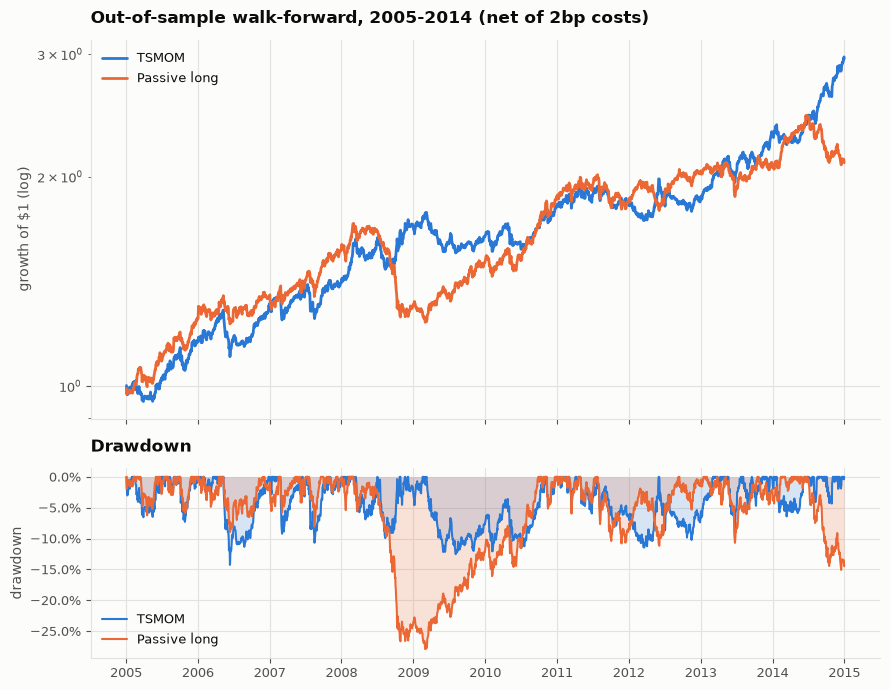

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})
plotting.growth_chart(growth_of_one(wf['strategy']), growth_of_one(wf['benchmark']),
                      'Out-of-sample walk-forward, 2005-2014 (net of 2bp costs)', ax=ax1)
plotting.drawdown_chart(wf['strategy'], wf['benchmark'], 'Drawdown', ax=ax2)
plt.tight_layout()
plt.savefig(f'{FIGURES}/walk_forward.png')
plt.show()

This chart is worth reading carefully, because it is less one-sided than the Sharpe ratios suggest, and because the *relative* and *absolute* stories differ.

**Most of the advantage over the passive book is opened in 2008** — but not by the trend book surging. It held roughly flat through the crash, short equities and long bonds, while the passive book lost about a quarter of its value. The gap is the control falling, not TSMOM rising, and §4 shows that 2008–09 was in fact the trend book's *weakest* stretch of the decade in absolute terms.

**From 2010 to mid-2014 the two run close together**, with the passive book ahead for much of 2011–2012. An investor holding this instead of a simple long book would have spent two years wondering why.

**The two diverge sharply again in the second half of 2014**, when the oil collapse gave trend followers a large, persistent short to hold and the long-only book took it on the chin — the same mechanism as 2008, in the opposite asset class.

So the honest description is not "TSMOM steadily outperforms". It is that the *margin* is earned in a handful of dislocations and is close to nil in between, which is exactly the payoff profile §9 makes explicit — and exactly why §3 finds that margin statistically indistinguishable from zero.

### 2. Held-out window: 2010–2014

A stricter, simpler test: fix everything using data through 2009 and never look at 2010–2014 until the end. Five years, exactly the brief's minimum.

In [6]:
returns = instrument_returns(universe)
result = diversified_tsmom(universe, cost_bps=COSTS_BPS, returns=returns,
                           portfolio_vol_target=VOL_TARGET)

windows = {'in-sample 1978-2009': slice(None, '2009-12-31'), 'held-out 2010-2014': OOS}
rows = []
for label, w in windows.items():
    for book, series in [('TSMOM', result['strategy']), ('Passive long', result['benchmark'])]:
        rows.append({'window': label, 'book': book, **performance(series.loc[w])})

pd.DataFrame(rows).style.format(FORMATS).hide(axis='index')

window,book,Sharpe,t-stat,ann. return,ann. vol,max drawdown
in-sample 1978-2009,TSMOM,1.72,9.58,18.5%,10.1%,-14.3%
in-sample 1978-2009,Passive long,0.46,2.58,4.2%,10.0%,-54.2%
held-out 2010-2014,TSMOM,1.27,2.90,12.8%,9.8%,-12.0%
held-out 2010-2014,Passive long,0.70,1.60,6.6%,9.8%,-14.6%


Two things to read here, and the second is less flattering than the first.

**The strategy holds up out-of-sample**: Sharpe 1.27 on data never used to make any design decision, at t = 2.90, with a smaller drawdown than the control. For a strategy whose parameters were fixed by the literature rather than fitted, that is the expected and reassuring outcome.

**But the in-sample number is not a forecast.** TSMOM's Sharpe falls from 1.72 in-sample to 1.27 out-of-sample. I read the 1.72 as an upper bound inflated by unmodelled frictions across a 32-year window that includes the 1970s–80s commodity trends, not as an estimate of what the strategy earns going forward. Everything this notebook claims is led by the out-of-sample figures.

### 3. Is any of this significant?

A Sharpe ratio is a point estimate from one path of a fat-tailed, serially-correlated series. Quoted alone it invites reading a gap of 0.3 as a result. So every headline number below carries a **circular block bootstrap** interval — resampling in 21-day blocks to preserve volatility clustering, with wrap-around so the extremes at the edges of the sample (2008) are not under-sampled.

Two separate questions, and they get different answers.

In [7]:
def significance(strategy, benchmark, label):
    own = sharpe_interval(strategy)
    gap = sharpe_difference_interval(strategy, benchmark)
    return [{'window': label, 'question': "TSMOM's own Sharpe", **own},
            {'window': label, 'question': 'TSMOM minus passive long', **gap}]

sig = (significance(wf['strategy'], wf['benchmark'], 'walk-forward 2005-2014')
       + significance(result['strategy'].loc[OOS], result['benchmark'].loc[OOS],
                      'held-out 2010-2014'))

pd.DataFrame(sig)[['window', 'question', 'estimate', 'ci_low', 'ci_high', 'p_positive']].style.format(
    {'estimate': '{:+.2f}', 'ci_low': '{:+.2f}', 'ci_high': '{:+.2f}', 'p_positive': '{:.1%}'}
).hide(axis='index')

window,question,estimate,ci_low,ci_high,p_positive
walk-forward 2005-2014,TSMOM's own Sharpe,+1.08,+0.42,+1.74,100.0%
walk-forward 2005-2014,TSMOM minus passive long,+0.33,-0.51,+1.14,77.5%
held-out 2010-2014,TSMOM's own Sharpe,+1.27,+0.34,+2.27,99.9%
held-out 2010-2014,TSMOM minus passive long,+0.57,-0.63,+1.80,81.7%


findfont: Failed to find font weight demibold, now using 700.


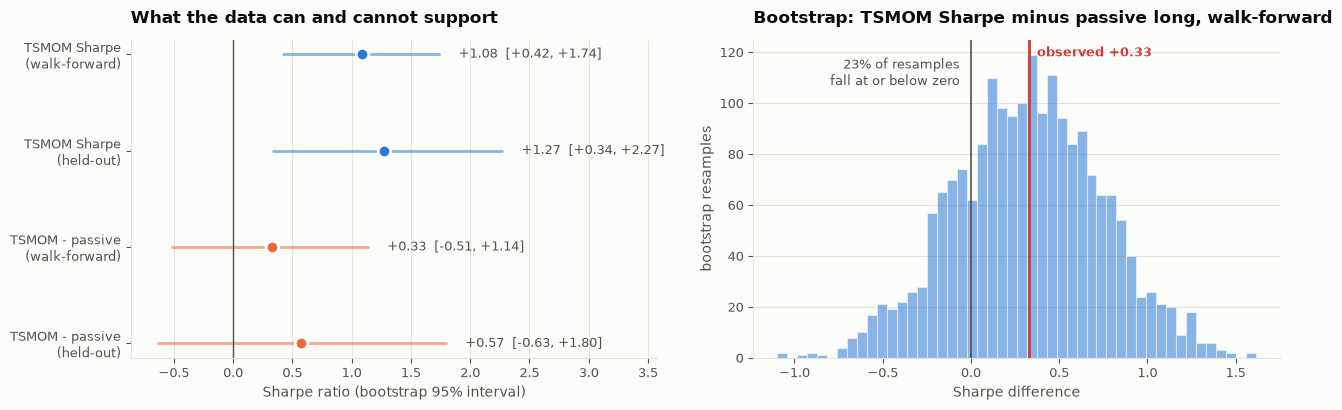

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

rows = [{'label': "TSMOM Sharpe\n(walk-forward)", 'colour': plotting.STRATEGY, **sig[0]},
        {'label': "TSMOM Sharpe\n(held-out)", 'colour': plotting.STRATEGY, **sig[2]},
        {'label': 'TSMOM - passive\n(walk-forward)', 'colour': plotting.BENCHMARK, **sig[1]},
        {'label': 'TSMOM - passive\n(held-out)', 'colour': plotting.BENCHMARK, **sig[3]}]
plotting.interval_chart(rows, 'What the data can and cannot support',
                        'Sharpe ratio (bootstrap 95% interval)', ax=ax1)

paired = pd.DataFrame({'s': wf['strategy'], 'b': wf['benchmark']}).dropna()
draws = block_bootstrap(paired, lambda d: sharpe_ratio(d['s']) - sharpe_ratio(d['b']))
plotting.bootstrap_density(draws, sig[1]['estimate'],
                           'Bootstrap: TSMOM Sharpe minus passive long, walk-forward',
                           'Sharpe difference', ax=ax2)
plt.tight_layout()
plt.savefig(f'{FIGURES}/significance.png')
plt.show()

**The strategy's own Sharpe is comfortably significant.** Walk-forward t = 3.49, and the bootstrap interval [0.42, 1.74] is clear of zero in 100% of resamples. Held-out, t = 2.90 and the interval is [0.34, 2.27]. Ten years of out-of-sample data at t = 3.5 is a real result.

**The margin over the risk-matched control is not.** The point estimates are +0.33 and +0.57, but both intervals straddle zero — the walk-forward difference is positive in only 78% of resamples, well short of any conventional threshold. Two series can each have a significant Sharpe while their *difference* is indistinguishable from zero, and that is exactly what happens here: the difference statistic has far less power than either level, because both books share a +0.30 correlation and only 10 years of data.

I could have led this write-up with "TSMOM beats a passive book on every window tested". It is true of the point estimates, and it would have been the wrong claim to make. What the evidence supports is that **this is a genuinely profitable, low-correlation book** — and §5 shows that is the more useful property anyway.

### 4. Was the record earned evenly?

A single Sharpe cannot distinguish a strategy that earned it steadily from one that earned it in a single year. Since §1 showed the *margin* over the control being opened almost entirely in 2008, the obvious worry is that the strategy's own return is just as concentrated. Worth measuring rather than assuming.

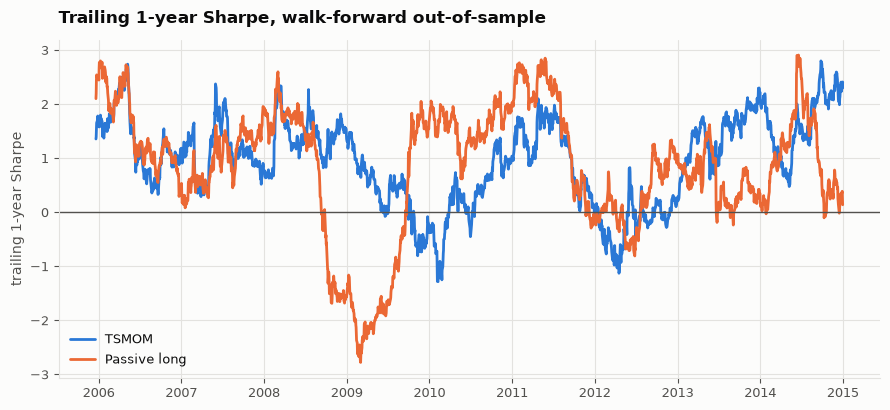

sub-period,Sharpe,t-stat,ann. return,ann. vol,max drawdown
2005-2007,1.10,1.94,11.7%,10.5%,-14.3%
2008-2009 (crisis),0.75,1.08,7.7%,10.6%,-12.5%
2010-2014,1.22,2.77,12.2%,9.8%,-11.4%


In [9]:
fig, ax = plt.subplots(figsize=(9, 4.2))
plotting.rolling_sharpe_chart(
    {'TSMOM': rolling_sharpe(wf['strategy']), 'Passive long': rolling_sharpe(wf['benchmark'])},
    'Trailing 1-year Sharpe, walk-forward out-of-sample', '1-year', ax=ax)
plt.tight_layout()
plt.savefig(f'{FIGURES}/rolling_sharpe.png')
plt.show()

spans = {'2005-2007': slice('2005-01-01', '2007-12-31'),
         '2008-2009 (crisis)': slice('2008-01-01', '2009-12-31'),
         '2010-2014': OOS}
pd.DataFrame([{'sub-period': k, **performance(wf['strategy'].loc[v])} for k, v in spans.items()]
             ).style.format(FORMATS).hide(axis='index')

The trailing Sharpe spends most of the decade positive but goes negative in 2009, 2012 and briefly 2013 — a trend follower's normal life, and the source of the career risk in actually holding one.

The sub-period table answers the question the equity curve raises, and the answer is the opposite of what I expected: **the record is not carried by the crisis.** 2008–09 is the *weakest* block (Sharpe 0.75), while 2005–07 returns 1.10 and 2010–14 returns 1.22. The book-level volatility target is part of why — it de-levered into the 2008 turbulence, trading some crisis upside for a −12.5% drawdown instead of a far larger one.

This matters for how much weight to put on the headline. A ten-year Sharpe driven entirely by one extraordinary year would be a much weaker result than one earned across three quite different regimes, and this is the second. It also sharpens §1: 2008 is where TSMOM's *margin over the passive book* comes from, not where its own return comes from.

### 5. Against benchmarks anyone can actually buy — and the allocator's question

The risk-matched control answers "does the signal work?". It cannot answer "should I own this?", because nobody can buy it. So: how does the trend book compare to what an allocator already holds, and — the question that actually matters for a near-zero-correlation strategy — **what does adding it to a normal portfolio do?**

In [10]:
references = reference_books(returns=returns)
books = {'TSMOM': result['strategy'], **references}

# NOTE: this table evaluates the full-universe book over the walk-forward DATE RANGE, so
# its 2005-2014 Sharpe (1.14) is slightly above the true point-in-time walk-forward figure
# reported in the headline (1.08). The reference books have no universe to re-select, so
# comparing them on a common date range is the like-for-like choice here.
comparison = []
for label, w in [('walk-forward window 2005-2014', WF), ('held-out 2010-2014', OOS)]:
    for name, series in books.items():
        comparison.append({'window': label, 'book': name, **performance(series.loc[w])})

pd.DataFrame(comparison).style.format(FORMATS).hide(axis='index')

window,book,Sharpe,t-stat,ann. return,ann. vol,max drawdown
walk-forward window 2005-2014,TSMOM,1.14,3.67,11.8%,10.2%,-14.3%
walk-forward window 2005-2014,Equity (S&P futures),0.36,1.15,5.5%,20.5%,-57.5%
walk-forward window 2005-2014,60/40 equity/bonds,0.53,1.67,5.6%,11.7%,-33.5%
held-out 2010-2014,TSMOM,1.27,2.90,12.8%,9.8%,-12.0%
held-out 2010-2014,Equity (S&P futures),0.94,2.10,14.9%,16.1%,-19.3%
held-out 2010-2014,60/40 equity/bonds,1.25,2.79,11.3%,8.9%,-9.3%


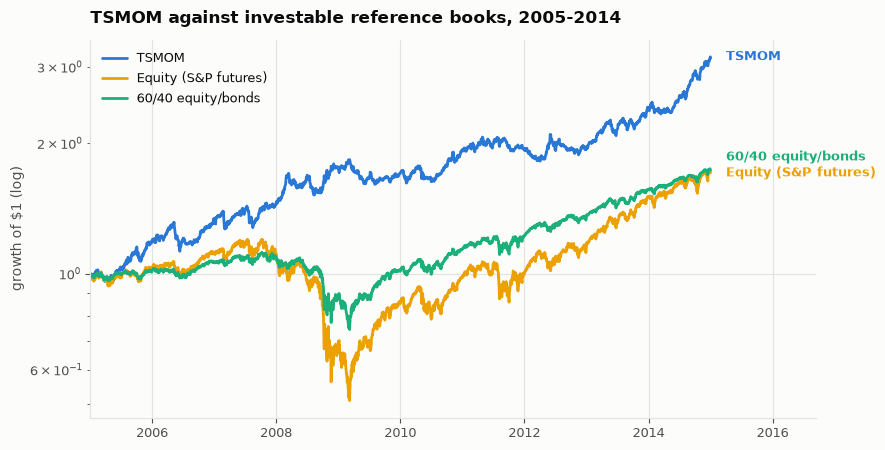

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.6))
plotting.multi_growth_chart({k: v.loc[WF] for k, v in books.items()},
                            'TSMOM against investable reference books, 2005-2014', ax=ax)
plt.tight_layout()
plt.savefig(f'{FIGURES}/reference_books.png')
plt.show()

Read this honestly: over **2010–2014 a plain 60/40 portfolio matched the trend book** — Sharpe 1.25 against 1.27 is a tie, and 60/40 achieved it with almost no turnover, no shorting and no leverage. That window was a bond bull market alongside a post-crisis equity recovery: close to the best possible five years for simply being long, and a widely-documented weak period for managed futures. Over the full walk-forward decade, which includes 2008, TSMOM is well ahead of both reference books.

But neither comparison is the right one, because **TSMOM is not a replacement for a 60/40 portfolio — it is a diversifier for one.** Its correlation to 60/40 is +0.30. The test that matters is what happens when you hold both.

In [12]:
core = references['60/40 equity/bonds']
allocations = [0.0, 0.10, 0.20, 0.30]

rows = []
for label, w in [('walk-forward window 2005-2014', WF), ('held-out 2010-2014', OOS)]:
    for weight in allocations:
        mixed = blend(core, result['strategy'], weight).loc[w]
        rows.append({'window': label, 'TSMOM sleeve': f'{weight:.0%}', **performance(mixed)})

pd.DataFrame(rows).style.format(FORMATS).hide(axis='index')

window,TSMOM sleeve,Sharpe,t-stat,ann. return,ann. vol,max drawdown
walk-forward window 2005-2014,0%,0.53,1.67,5.6%,11.7%,-33.5%
walk-forward window 2005-2014,10%,0.63,2.00,6.3%,10.6%,-28.5%
walk-forward window 2005-2014,20%,0.75,2.38,7.0%,9.6%,-23.5%
walk-forward window 2005-2014,30%,0.88,2.79,7.6%,8.8%,-19.2%
held-out 2010-2014,0%,1.25,2.79,11.3%,8.9%,-9.3%
held-out 2010-2014,10%,1.34,2.99,11.5%,8.4%,-8.8%
held-out 2010-2014,20%,1.42,3.17,11.6%,8.0%,-8.3%
held-out 2010-2014,30%,1.48,3.31,11.8%,7.7%,-7.9%


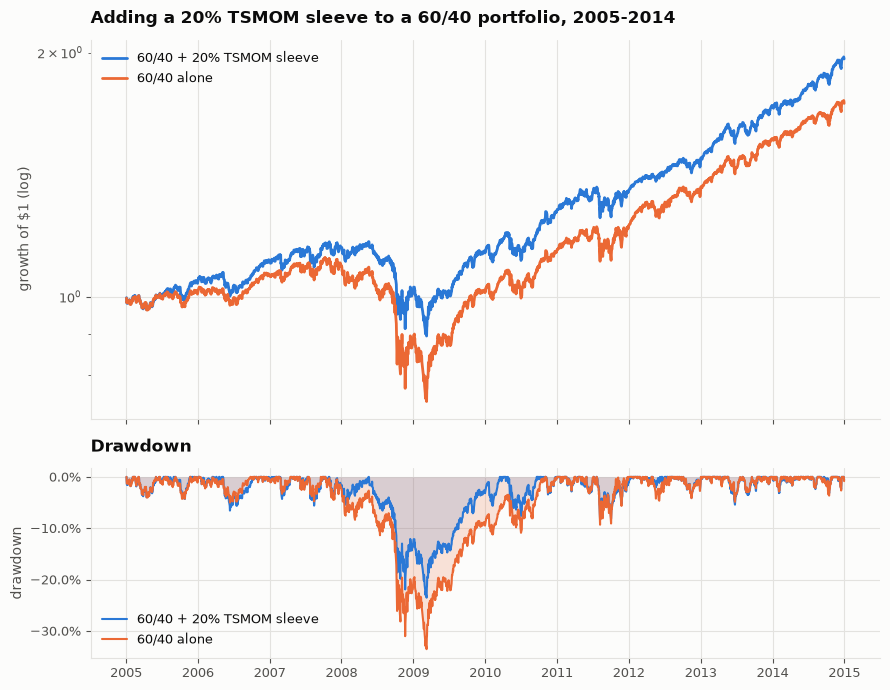

In [13]:
mixed_20 = blend(core, result['strategy'], 0.20)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})
LABELS = ('60/40 + 20% TSMOM sleeve', '60/40 alone')
plotting.growth_chart(growth_of_one(mixed_20.loc[WF]), growth_of_one(core.loc[WF]),
                      'Adding a 20% TSMOM sleeve to a 60/40 portfolio, 2005-2014',
                      ax=ax1, labels=LABELS)
plotting.drawdown_chart(mixed_20.loc[WF], core.loc[WF], 'Drawdown', ax=ax2, labels=LABELS)
plt.tight_layout()
plt.savefig(f'{FIGURES}/allocator_view.png')
plt.show()

**This is the strongest result in the project.** A 20% sleeve funded out of a 60/40 portfolio, over the walk-forward decade:

- Sharpe **0.53 → 0.75**
- Max drawdown **−33.5% → −23.5%**
- Annualised return **5.6% → 7.0%**, at *lower* volatility (11.7% → 9.6%)

Higher return, lower risk, and a third off the worst drawdown. The improvement holds out-of-sample too (1.25 → 1.42), in the five years when the trend book merely *tied* 60/40 standalone — which is precisely the point of a diversifier, and precisely what a horse race between standalone Sharpe ratios cannot show. A book with a +0.30 correlation adds value through what it does in the other book's bad quarters (§9), not through winning on its own.

Note also that the allocator result is monotone in the sleeve weight across the range tested, so it does not depend on picking 20%.

### 6. Why the book-level volatility target earns its place

Sizing each market to 40% volatility does not make the *portfolio's* volatility constant — that also depends on cross-market correlation and on how many markets are live, both of which move a lot over 36 years. This is the one addition I made beyond the canonical MOP specification, and it is Hurst-Ooi-Pedersen's, not mine.

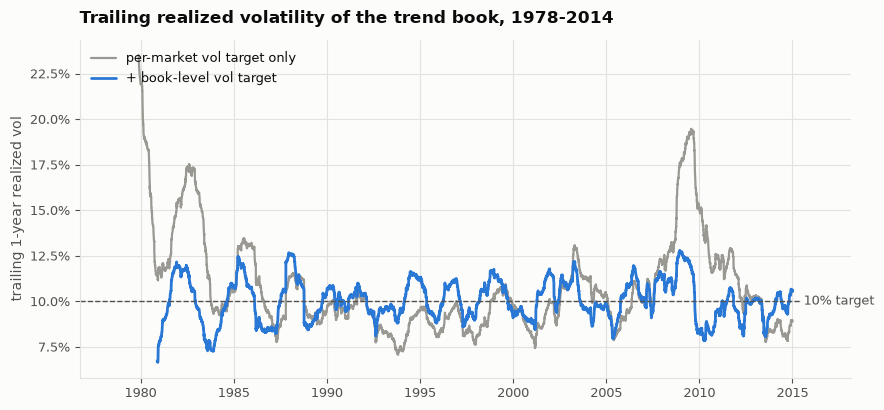

book,Sharpe,t-stat,ann. return,ann. vol,max drawdown
per-market vol target only (MOP),0.93,2.99,11.0%,12.0%,-22.7%
+ book-level vol target (HOP),1.08,3.49,11.1%,10.2%,-14.3%


In [14]:
plain = diversified_tsmom(universe, cost_bps=COSTS_BPS, returns=returns)
before = (plain['strategy'].rolling(252).std() * np.sqrt(252)).dropna()
after = (result['strategy'].rolling(252).std() * np.sqrt(252)).dropna()

fig, ax = plt.subplots(figsize=(9, 4.2))
plotting.vol_target_chart(before, after, VOL_TARGET,
                          'Trailing realized volatility of the trend book, 1978-2014', ax=ax)
plt.tight_layout()
plt.savefig(f'{FIGURES}/vol_target.png')
plt.show()

wf_plain = walk_forward(start_year=2005, end_year=2014, cost_bps=COSTS_BPS)
pd.DataFrame([
    {'book': 'per-market vol target only (MOP)', **performance(wf_plain['strategy'])},
    {'book': '+ book-level vol target (HOP)', **performance(wf['strategy'])},
]).style.format(FORMATS).hide(axis='index')

Without the overlay the book's realised risk ranges from 7.1% to 19.5% (5th-95th percentile 8.1%–16.1%, standard deviation 2.4pp) — and it runs its *largest* risk in 2008, exactly when an investor can least afford it. With the overlay the range narrows to 7.3%–12.8% (5th-95th 8.3%–12.0%, standard deviation 1.1pp): less than half the variation in risk, and no crisis spike. It does not pin volatility exactly at 10%, and cannot — leverage is set from *trailing* realised vol, so it responds to a change in risk rather than anticipating one.

On the walk-forward window this raises Sharpe **0.93 → 1.08** and cuts max drawdown **−22.7% → −14.3%** at essentially unchanged return. Three reasons I am comfortable treating this as a real improvement rather than a fitted one:

1. **It is specified by a paper**, not chosen from a grid — 10% annualised on a trailing 1-year vol estimate is HOP's own convention.
2. **The 10% is a units convention, not a parameter.** Sharpe is invariant to constant rescaling; only the *time variation* in leverage can affect it.
3. **It is charged for.** Leverage is applied to positions, not to the finished return series, so every re-levering trade pays the same 2bp as any other trade. (There is a regression test for exactly this — scaling returns instead would have made de-levering into a crisis look free.)

Applied symmetrically to the control, it *lowers* the control's Sharpe slightly (0.80 → 0.76), so this is not an overlay that flatters whatever it touches.

### 7. Breadth is not a detail of the strategy — it is the strategy

The most common suggestion made about a book like this is "trade fewer, better markets" — concentrate into the instruments that look most tractable. It is worth testing rather than assuming, because per-market Sharpes here are only around 0.2–0.3: almost the entire portfolio result is a diversification effect.

Two tests. First, how Sharpe scales with the *number* of markets, using random subsets — random rather than "the best N", because any rule for choosing which markets to keep would itself be a hindsight decision.

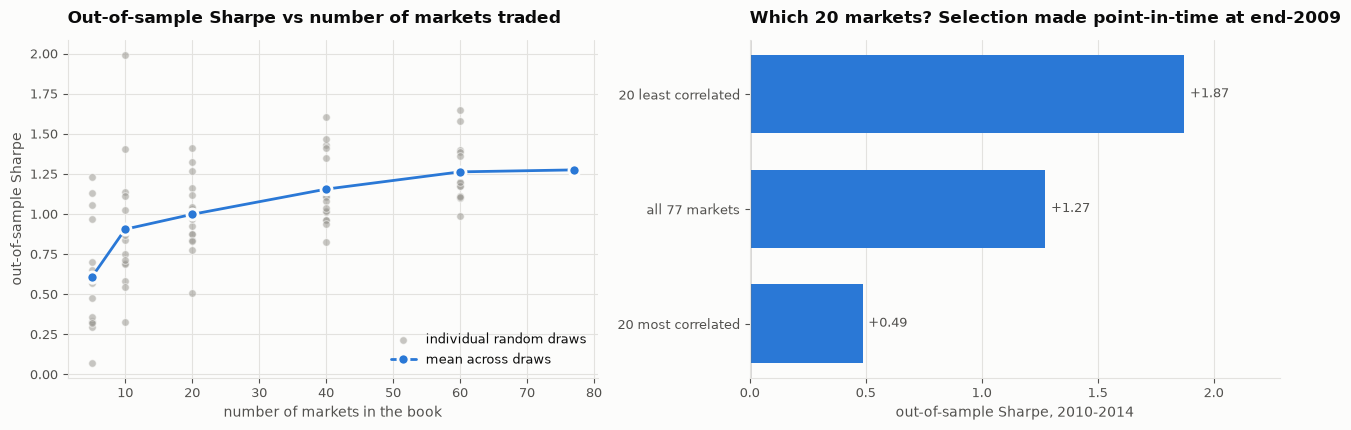

,mean,std,min,max
n_markets,,,,
5,0.61,0.35,0.07,1.23
10,0.91,0.40,0.33,1.99
20,1.00,0.24,0.51,1.41
40,1.16,0.23,0.82,1.61
60,1.26,0.18,0.99,1.65
77,1.27,nan,1.27,1.27


In [15]:
breadth = universe_breadth_study(universe, sizes=[5, 10, 20, 40, 60, len(universe)],
                                 window=OOS, n_draws=15, cost_bps=COSTS_BPS, returns=returns,
                                 portfolio_vol_target=VOL_TARGET)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))
plotting.breadth_chart(breadth, 'Out-of-sample Sharpe vs number of markets traded', ax=ax1)

as_of = '2009-12-31'
concentration = {}
for label, most in [('20 most correlated', True), ('20 least correlated', False)]:
    subset = correlation_ranked_universe(universe, 20, as_of, most_correlated=most, returns=returns)
    book = diversified_tsmom(subset, cost_bps=COSTS_BPS, portfolio_vol_target=VOL_TARGET,
                             returns={s: returns[s] for s in subset})
    concentration[label] = sharpe_ratio(book['strategy'].loc[OOS])
concentration['all 77 markets'] = sharpe_ratio(result['strategy'].loc[OOS])

plotting.diverging_barh(pd.Series(concentration),
                        'Which 20 markets? Selection made point-in-time at end-2009',
                        'out-of-sample Sharpe, 2010-2014', ax=ax2)
plt.tight_layout()
plt.savefig(f'{FIGURES}/breadth.png')
plt.show()

breadth.groupby('n_markets')['sharpe'].agg(['mean', 'std', 'min', 'max']).style.format('{:.2f}')

Mean out-of-sample Sharpe rises monotonically with breadth — 0.61 at five markets, 0.91 at ten, 1.16 at forty, 1.27 at all 77 — and the *dispersion* collapses as breadth grows (standard deviation across draws 0.35 → 0.18). A five-market book is not merely worse on average; which five you happened to pick matters more than the strategy does. Note the spread at ten markets: the luckiest draw returned 1.99 and the unluckiest 0.33. That is the definition of a result you cannot rely on.

The second panel asks *which* markets, with the selection made **point-in-time using only data through 2009** so the ranking cannot cheat. Concentrating into the 20 most mutually correlated markets gives an out-of-sample Sharpe of **0.49**; the 20 least correlated give **1.87**, against 1.27 for the full book. Correlated markets are the same bet wearing different tickers — the book pays full transaction costs for the privilege of holding it several times.

This is why the universe is 77 markets and not five, and it is the clearest evidence in the project that **the edge is diversification, not prediction**. (The 1.87 figure is a legitimate out-of-sample number, but I have not adopted it as the strategy: a point-in-time correlation screen is one more design decision, and the whole argument of this section is that fewer, cleverer choices is the losing direction.)

### 8. Where the return comes from

A single portfolio number can hide a result driven by one lucky market or sector. Per-asset-class, out-of-sample:

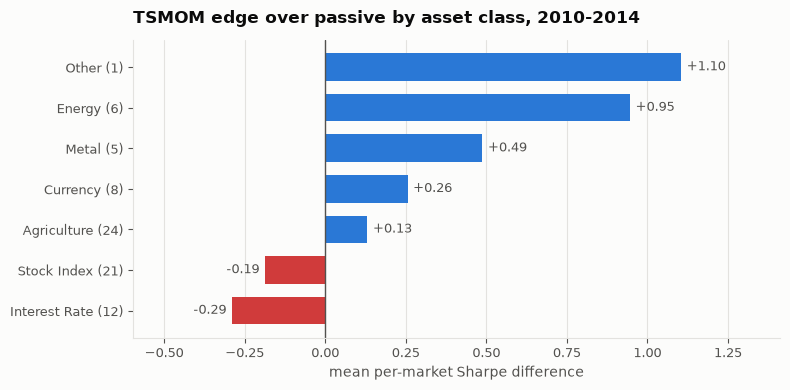

In [16]:
oos_strategy = result['per_instrument_strategy'].loc[OOS]
oos_benchmark = result['per_instrument_benchmark'].loc[OOS]

gap = pd.DataFrame({
    'class': [catalogue[s] for s in oos_strategy.columns],
    'tsmom': oos_strategy.apply(sharpe_ratio),
    'passive': oos_benchmark.apply(sharpe_ratio),
})
gap['edge'] = gap['tsmom'] - gap['passive']
counts = gap['class'].value_counts()
by_class = gap.groupby('class')['edge'].mean()
by_class.index = [f'{name} ({counts[name]})' for name in by_class.index]

fig, ax = plt.subplots(figsize=(8, 4))
plotting.diverging_barh(by_class, 'TSMOM edge over passive by asset class, 2010-2014',
                        'mean per-market Sharpe difference', ax=ax)
plt.tight_layout()
plt.savefig(f'{FIGURES}/edge_by_class.png')
plt.show()

The edge is **broad but not universal** — strongly positive in energy and metals, mildly positive in currencies and agriculture, and *negative* in stock indices and interest rates over this window. Market counts are in brackets; 'Other' is a single contract and should not be read as a class average.

The two negative classes are the ones that trended smoothly upward through 2010–2014 (post-crisis equities, and bonds as rates fell toward zero) — periods when simply being long was hard to beat. This is the same story the equity curve tells, decomposed.

### 9. Crisis behaviour — the 'trend-following smile'

Trend-following's most-cited property is that it tends to do *well* when equities do badly, because bear markets usually unfold over months (long enough to position short) rather than in a single day. Moskowitz-Ooi-Pedersen plot this as a smile. Reproducing it here is a strong test of whether this implementation behaves like the literature's.

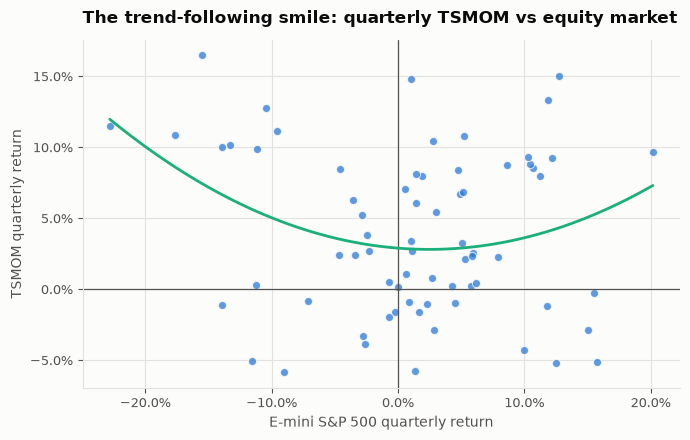

worst 20% of equity quarters (mean -12.3%): TSMOM +5.9%
best  20% of equity quarters (mean +12.9%): TSMOM +4.5%
quarterly correlation with equities: -0.13


In [17]:
equity = returns['&ES']
quarterly_strategy = (1 + result['strategy']).resample('QE').prod() - 1
quarterly_equity = (1 + equity).resample('QE').prod() - 1
smile = pd.DataFrame({'equity': quarterly_equity, 'tsmom': quarterly_strategy}).dropna()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.axhline(0, color=plotting.TEXT_SECONDARY, linewidth=0.9)
ax.axvline(0, color=plotting.TEXT_SECONDARY, linewidth=0.9)
ax.scatter(smile['equity'], smile['tsmom'], s=34, color=plotting.STRATEGY,
           alpha=0.75, edgecolor=plotting.SURFACE, linewidth=0.8)

fit = np.polyfit(smile['equity'], smile['tsmom'], 2)
grid = np.linspace(smile['equity'].min(), smile['equity'].max(), 200)
ax.plot(grid, np.polyval(fit, grid), color=plotting.ACCENT, linewidth=2)

ax.set_title('The trend-following smile: quarterly TSMOM vs equity market')
ax.set_xlabel('E-mini S&P 500 quarterly return')
ax.set_ylabel('TSMOM quarterly return')
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig(f'{FIGURES}/smile.png')
plt.show()

worst = smile[smile['equity'] < smile['equity'].quantile(0.2)]
best = smile[smile['equity'] > smile['equity'].quantile(0.8)]
print(f"worst 20% of equity quarters (mean {worst['equity'].mean():+.1%}): "
      f"TSMOM {worst['tsmom'].mean():+.1%}")
print(f"best  20% of equity quarters (mean {best['equity'].mean():+.1%}): "
      f"TSMOM {best['tsmom'].mean():+.1%}")
print(f"quarterly correlation with equities: {smile['equity'].corr(smile['tsmom']):+.2f}")

The smile is there. The strategy makes money in the *worst* equity quarters (+5.9% on average, when equities average −12.3%) and the *best* ones (+4.5%), and is close to uncorrelated in between — the diversification property that makes trend-following worth allocating to, reproduced independently here. It is also the mechanism behind §5: a book that pays off in the quarters a 60/40 portfolio suffers most is worth owning even at a lower standalone Sharpe.

### 10. How much the cost assumption actually matters

Two questions: how much money the costs are, and whether the conclusion depends on the rate being right.

The size of the drag is set by **turnover** — a per-trade charge only becomes an annual number once you know how often the book trades. This is also the quantitative version of the fairness argument in the Costs section above.

In [18]:
def annual_turnover(positions, window):
    """Notional traded per unit of capital, per year.

    `portfolio_mean` applies the same 1/N the returns get, so this is expressed per unit
    of PORTFOLIO capital and is directly comparable across books of different size.
    """
    daily = portfolio_mean(positions.diff().abs()).loc[window]
    return daily.mean() * 252


rows = []
for label, key in [('TSMOM', 'strategy'), ('Passive long', 'benchmark')]:
    turns = annual_turnover(result[f'{key}_positions'], WF)
    rows.append({'book': label,
                 'turnover (x capital / yr)': turns,
                 'cost drag at 2bp': turns * COSTS_BPS / 1e4})

pd.DataFrame(rows).style.format(
    {'turnover (x capital / yr)': '{:.1f}x', 'cost drag at 2bp': '{:.2%}'}
).hide(axis='index')

book,turnover (x capital / yr),cost drag at 2bp
TSMOM,50.6x,1.01%
Passive long,8.1x,0.16%


The trend book pays roughly **1% a year** to trade; the passive control pays about **0.16%**. That gap — near enough 0.85%/yr — is what a gross comparison would silently have handed the strategy, and it is the whole reason costs are charged to both legs on the same basis rather than only to the one being tested.

The remaining question is whether 2bp is *right*. It is an assumed number (see Costs above), so the conclusion should not hinge on it:

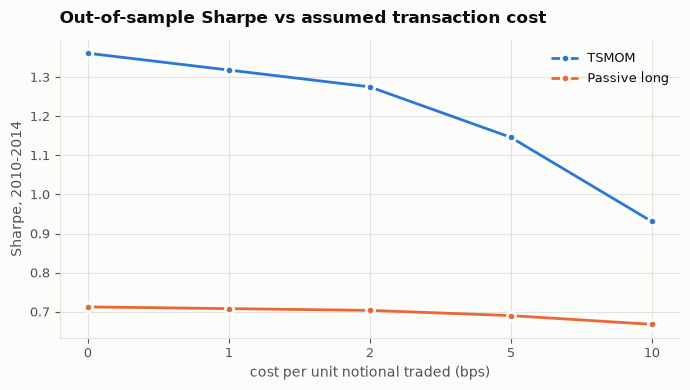

,TSMOM,Passive long
cost (bps),,
0,1.36,0.71
1,1.32,0.71
2,1.27,0.70
5,1.15,0.69
10,0.93,0.67


In [19]:
cost_rows = []
for bps in [0.0, 1.0, 2.0, 5.0, 10.0]:
    r = diversified_tsmom(universe, cost_bps=bps, returns=returns,
                          portfolio_vol_target=VOL_TARGET)
    cost_rows.append({'cost (bps)': bps,
                      'TSMOM': sharpe_ratio(r['strategy'].loc[OOS]),
                      'Passive long': sharpe_ratio(r['benchmark'].loc[OOS])})

costs = pd.DataFrame(cost_rows).set_index('cost (bps)')
costs.index = costs.index.map('{:.0f}'.format)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(costs.index, costs['TSMOM'], color=plotting.STRATEGY, marker='o', markersize=6,
        markeredgecolor=plotting.SURFACE, markeredgewidth=2.0, label='TSMOM')
ax.plot(costs.index, costs['Passive long'], color=plotting.BENCHMARK, marker='o', markersize=6,
        markeredgecolor=plotting.SURFACE, markeredgewidth=2.0, label='Passive long')
ax.set_title('Out-of-sample Sharpe vs assumed transaction cost')
ax.set_xlabel('cost per unit notional traded (bps)')
ax.set_ylabel('Sharpe, 2010-2014')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES}/cost_sensitivity.png')
plt.show()

costs.style.format('{:.2f}')

The strategy stays clearly profitable across the whole range, and the ordering against the control survives throughout. For liquid global futures 2bp is a reasonable central estimate; the honest statement is that **the result depends on trading costs being low**, which is exactly why this strategy is run in futures rather than less liquid instruments.

### 11. The regime overlay

Hurst-Ooi-Pedersen find that trend-following does worse when markets move together — when average cross-market correlation is high, there are fewer genuinely distinct bets to make. Implemented as a risk dial: **halve exposure when average pairwise correlation is above its own trailing median**, full exposure otherwise.

In [20]:
regime = correlation_regime_scale(universe, corr_window=120, threshold_lookback=504,
                                  returns=returns)
overlay_wf = walk_forward(start_year=2005, end_year=2014, cost_bps=COSTS_BPS,
                          portfolio_vol_target=VOL_TARGET, regime_scale=regime)

pd.DataFrame([{'book': 'TSMOM', **performance(wf['strategy'])},
              {'book': 'TSMOM + correlation overlay', **performance(overlay_wf['strategy'])}]
             ).style.format(FORMATS).hide(axis='index')

book,Sharpe,t-stat,ann. return,ann. vol,max drawdown
TSMOM,1.08,3.49,11.1%,10.2%,-14.3%
TSMOM + correlation overlay,1.21,3.87,13.0%,10.6%,-12.5%


The overlay is **reported as a secondary result, not folded into the headline**, because its specification (120-day window, 504-day median, halving rule) was chosen with full-sample knowledge. Two checks were run before believing it at all: that the timing carries information (a randomly re-aligned overlay with the same duty cycle averages ~0.93 Sharpe versus ~1.19 actual — roughly three standard deviations), and that it survives out-of-sample. Both are in `02_strategy_research.ipynb` §Part 3.

Note that it adds much less on top of the book-level vol target than it did without one — unsurprising, since both are risk dials that cut exposure in correlated, high-volatility regimes, and the vol target gets there first using a cleaner signal. **The core claim of this project stands without the overlay.**

### 12. What I tested and rejected

Reporting only what worked would misrepresent the process. Three things were built, tested and left out. All three are reproducible in `02_strategy_research.ipynb` — the blend and the concentration tests in Part 4, the trend-efficiency overlay in Part 1.

| Idea | Source | Result | Verdict |
|---|---|---|---|
| **Multi-horizon signal blend** (1/3/12-month) | Hurst-Ooi-Pedersen | walk-forward 1.14 → **1.20**, held-out 1.27 → **1.07** | **Not adopted.** It helps in one window by as much as it hurts in the other — the signature of noise, not of an improvement. |
| **Trend-efficiency boost** (Kaufman Efficiency Ratio) | targeted at a mechanism found in `02` | no improvement in risk-adjusted terms | **Rejected**, kept in `strategies.py` only so the negative result stays runnable. |
| **Concentrating the universe** | the standard suggestion | OOS Sharpe 1.27 → 0.49 (20 most-correlated markets) | **Rejected** — see §7. Actively harmful. |

The multi-horizon blend is the one I would flag to a reader, because it is the one where a results-shopping version of this project would have gone wrong. It is well-supported in the literature and I expected it to help. Measured on the walk-forward window it *does* help (1.14 → 1.20) — and had I stopped there I would have adopted it. On the held-out window it hurts by a similar margin (1.27 → 1.07). Both moves are comfortably inside the ~0.4 bootstrap standard error on a Sharpe difference from §3.

The honest reading is not "Hurst-Ooi-Pedersen are wrong" — they test 137 years and I have 10 of out-of-sample data. It is that **this dataset cannot resolve the question**, and when two specifications are statistically indistinguishable, Occam's razor picks the simpler one. That is also why the single-horizon signal stayed in the headline.

## Limitations

1. **The margin over the risk-matched control is not statistically significant** (§3). The strategy's own Sharpe is; the horse race is not. This is the single most important caveat and it is why the write-up leads on absolute performance and portfolio contribution.
2. **No transaction costs beyond a flat 2bp.** No slippage model, no market impact, no financing or margin costs, no capacity constraint. §10 is the honest bound on this.
3. **The in-sample Sharpe (1.72) is higher than the literature reports** (MOP >1 gross; Hurst-Ooi-Pedersen 0.76 net of fees). I treat it as an upper bound reflecting unmodelled frictions, not a forecast.
4. **The universe screen was designed with full-sample knowledge**, even though the walk-forward re-applies it point-in-time. A genuinely clean test needs the rules fixed before seeing any data.
5. **The regime overlay's specification is in-sample**, as noted in §11.
6. **Data ends 2014-12-31**, so 'out-of-sample' means held-out history, not unseen recent data. Trend-following's post-2015 record is notably weaker than its history — this analysis cannot speak to that, and it is the limitation I would most want to close with more data.
7. **Execution is assumed at the daily close** on the vendor's roll schedule, with no spread paid on the roll itself.
8. **The 60/40 reference is built from futures**, so it is an excess-return proxy for a cash portfolio rather than an actual 60/40 fund, and it holds 10-year notes rather than a broad bond index.

## Key takeaways

1. **A diversified 12-month time-series momentum book earned a Sharpe of 1.08 over a ten-year rolling walk-forward and 1.27 over a five-year held-out window**, net of costs, at t = 3.5 and 2.9 respectively — with maximum drawdowns of −14% and −12%.

2. **Its value is as a diversifier, not a replacement.** Adding a 20% sleeve to a 60/40 portfolio raised Sharpe from 0.53 to 0.75 and cut max drawdown from −34% to −24% over the walk-forward decade — and still improved the portfolio out-of-sample in the window where the trend book only *tied* 60/40 standalone.

3. **The edge is diversification, not prediction.** Sharpe rises monotonically with breadth (0.61 at five markets → 1.27 at 77) and dispersion across draws halves; concentrating into the 20 most correlated markets cuts it to 0.49. This is the strategy's actual mechanism, measured rather than asserted.

4. **It behaves like the literature says it should.** The crisis smile reproduces independently: positive returns in the worst *and* best equity quarters, near-zero correlation in between.

5. **I can show the strategy works; I cannot show it beats its risk-matched control at conventional significance.** The bootstrap interval on that difference straddles zero. Stating this cost me the cleaner headline and is, I think, the most important thing in the notebook.

6. **Getting the futures return construction right mattered more than any modelling choice.** Using raw spliced continuous contracts injects roll carry that a permanently-long book harvests and a long/short book pays — enough to invert the headline conclusion. The audit that caught this is in `02_strategy_research.ipynb`.

---

**Reproducing this notebook**: `uv sync`, then `uv run jupyter lab`. Strategy logic lives in `src/cta/` (~1,100 lines, 69 tests in `tests/`); this notebook only orchestrates and plots. `01_data_exploration.ipynb` covers the data; `02_strategy_research.ipynb` is the full working log including the bug discovery and the rejected variants; `research/literature_notes.md` has the paper summaries.